# 線性迴歸的從零開始實現
:label:`sec_linear_scratch`

在了解線性迴歸的關鍵思想之後，我們可以開始通過代碼來動手實現線性迴歸了。
在這一節中，(**我們將從零開始實現整個方法，
包括資料流水線、模型、損失函數和小批量隨機梯度下降優化器**)。
雖然現代的深度學習框架幾乎可以自動化地進行所有這些工作，但從零開始實現可以確保我們真正知道自己在做什麼。
同時，了解更細緻的工作原理將方便我們自定義模型、自定義層或自定義損失函數。
在這一節中，我們將只使用張量和自動求導。
在之後的章節中，我們會充分利用深度學習框架的優勢，介紹更簡潔的實現方式。


In [2]:
%matplotlib inline
import random
import torch
import matplotlib.pyplot as plt

## 生成資料集

為了簡單起見，我們將[**根據帶有噪聲的線性模型構造一個人工資料集。**]
我們的任務是使用這個有限樣本資料集來恢復這個模型的參數。
我們將使用低維資料，這樣可以很容易地將其視覺化。
在下面的代碼中，我們生成一個包含1000個樣本資料集，
每個樣本包含從標準正態分布中採樣的2個特徵。
我們的合成資料集是一個矩陣$\mathbf{X}\in \mathbb{R}^{1000 \times 2}$。

(**我們使用線性模型參數$\mathbf{w} = [2, -3.4]^\top$、$b = 4.2$
和噪聲項$\epsilon$生成資料集及其標籤：

$$\mathbf{y}= \mathbf{X} \mathbf{w} + b + \mathbf\epsilon.$$
**)

$\epsilon$可以視為模型預測和標籤時的潛在觀測誤差。
在這裡我們認為標準假設成立，即$\epsilon$服從均值為0的正態分布。
為了簡化問題，我們將標準差設為0.01。
下面的代碼生成合成資料集。


In [3]:
def synthetic_data(w, b, num_examples):  #@save
    """生成y=Xw+b+噪声"""
    X = torch.normal(0, 1, (num_examples, len(w)))
    y = torch.matmul(X, w) + b
    y += torch.normal(0, 0.01, y.shape)
    return X, y.reshape((-1, 1))

In [4]:
true_w = torch.tensor([2, -3.4])
true_b = 4.2
features, labels = synthetic_data(true_w, true_b, 1000)

注意，[**`features`中的每一行都包含一個二維資料樣本，
`labels`中的每一行都包含一維標籤值（一個標量）**]。


In [5]:
print('features:', features[0],'\nlabel:', labels[0])

features: tensor([ 1.5384, -0.6729]) 
label: tensor([9.5585])


透過生成第二個特徵`features[:, 1]`和`labels`的散點圖，
可以直觀觀察到兩者之間的線性關係。


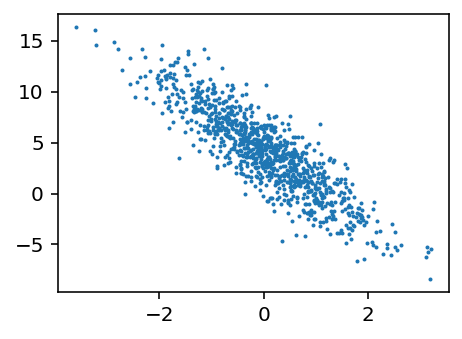

In [9]:
plt.rcParams['figure.figsize'] = (3.5, 2.5)
plt.rcParams['savefig.dpi'] = 144
plt.rcParams['figure.dpi'] = 144
plt.figure(figsize=(3.5, 2.5))
plt.scatter(features[:, (1)].detach().numpy(), labels.detach().numpy(), 1);

## 讀取資料集

回想一下，訓練模型時要對資料集進行遍歷，每次抽取一小批量樣本，並使用它們來更新我們的模型。
由於這個過程是訓練機器學習演算法的基礎，所以有必要定義一個函數，
該函數能打亂資料集中的樣本並以小批量方式獲取資料。

在下面的程式碼中，我們[**定義一個`data_iter`函數，
該函數接收批次大小、特徵矩陣和標籤向量作為輸入，生成大小為`batch_size`的小批次**]。
每個小批次包含一組特徵和標籤。


In [10]:
def data_iter(batch_size, features, labels):
    num_examples = len(features)
    indices = list(range(num_examples))
    # 这些样本是随机读取的，没有特定的顺序
    random.shuffle(indices)
    for i in range(0, num_examples, batch_size):
        batch_indices = torch.tensor(
            indices[i: min(i + batch_size, num_examples)])
        yield features[batch_indices], labels[batch_indices]

通常，我們利用GPU並行運算的優勢，處理合理大小的“小批量”。
每個樣本都可以並行地進行模型計算，且每個樣本損失函數的梯度也可以被並行計算。
GPU可以在處理幾百個樣本時，所花費的時間不比處理一個樣本時多太多。

我們直觀感受一下小批量運算：讀取第一個小批量資料樣本並打印。
每個批量的特徵維度顯示批量大小和輸入特徵數。
同樣的，批量的標籤形狀與`batch_size`相等。


In [11]:
batch_size = 10

for X, y in data_iter(batch_size, features, labels):
    print(X, '\n', y)
    break

tensor([[ 0.2849,  1.8320],
        [ 1.2164, -0.4487],
        [ 0.1915,  0.8818],
        [-0.1248, -0.1044],
        [ 0.3715,  0.3598],
        [ 0.3669, -0.0577],
        [ 0.7025,  1.1497],
        [-0.0563, -1.1533],
        [ 0.6138, -0.9380],
        [-0.1672, -1.9751]]) 
 tensor([[-1.4556],
        [ 8.1690],
        [ 1.5830],
        [ 4.3002],
        [ 3.7354],
        [ 5.1270],
        [ 1.7091],
        [ 8.0062],
        [ 8.6235],
        [10.5889]])


當我們運行迭代時，我們會連續地獲得不同的小批量，直至遍歷完整個資料集。
上面實現的迭代對教學來說很好，但它的執行效率很低，可能會在實際問題上陷入麻煩。
例如，它要求我們將所有資料加載到記憶體中，並執行大量的隨機記憶體存取。
在深度學習框架中實現的內置迭代器效率要高得多，
它可以處理存儲在檔案中的資料和資料流提供資料。

## 初始化模型參數

[**在我們開始用小批量隨機梯度下降優化我們的模型參數之前**]，
(**我們需要先有一些參數**)。
在下面的程式碼中，我們通過從均值為0、標準差為0.01的正態分布中採樣隨機數來初始化權重，
並將偏置初始化為0。


In [12]:
w = torch.normal(0, 0.01, size=(2,1), requires_grad=True)
b = torch.zeros(1, requires_grad=True)

在初始化參數之後，我們的任務是更新這些參數，直到這些參數足夠擬合我們的資料。
每次更新都需要計算損失函數關於模型參數的梯度。
有了這個梯度，我們就可以向減小損失的方向更新每個參數。
因為手動計算梯度很枯燥而且容易出錯，所以沒有人會手動計算梯度。
我們使用 :numref:`sec_autograd`中引入的自动微分來計算梯度。

## 定義模型

接下來，我們必須[**定義模型，將模型的輸入和參數同模型的輸出關聯起來。**]
回想一下，要計算線性模型的輸出，
我們只需計算輸入特徵$\mathbf{X}$和模型權重$\mathbf{w}$的矩陣-向量乘法後加上偏置$b$。
注意，上面的$\mathbf{Xw}$是一個向量，而$b$是一個標量。
回想一下 :numref:`subsec_broadcasting`中描述的廣播機制：
當我們用一個向量加一個標量時，標量會被加到向量的每個分量上。


In [13]:
def linreg(X, w, b):  #@save
    """線性迴歸模型"""
    return torch.matmul(X, w) + b

## [**定義損失函數**]

因為需要計算損失函數的梯度，所以我們應該先定義損失函數。
這裡我們使用 :numref:`sec_linear_regression`中描述的平方損失函數。
在實現中，我們需要將真實值`y`的形狀轉換為和預測值`y_hat`的形狀相同。


In [14]:
def squared_loss(y_hat, y):  #@save
    """均方损失"""
    return (y_hat - y.reshape(y_hat.shape)) ** 2 / 2

## (**定義優化算法**)

正如我們在 :numref:`sec_linear_regression`中討論的，線性迴歸有解析解。
儘管線性迴歸有解析解，但書中的其他模型卻沒有。
這裡我們介紹小批量隨機梯度下降。

在每一步中，使用從資料集中隨機抽取的一個小批量，然後根據參數計算損失的梯度。
接下來，朝著減少損失的方向更新我們的參數。
下面的函數實現小批量隨機梯度下降更新。
該函數接受模型參數集合、學習速率和批量大小作為輸入。每
一步更新的大小由學習速率`lr`決定。
因為我們計算的損失是一個批量樣本總和，所以我們用批量大小（`batch_size`）
來規範化步長，這樣步長大小就不會取決於我們對批量大小的選擇。


In [15]:
def sgd(params, lr, batch_size):  #@save
    """小批量隨機梯度下降"""
    with torch.no_grad():
        for param in params:
            param -= lr * param.grad / batch_size
            param.grad.zero_()

## 訓練

現在我們已經準備好了模型訓練所有需要的要素，可以實現主要的[**訓練過程**]部分了。
理解這段代碼至關重要，因為從事深度學習後，
相同的訓練過程幾乎一遍又一遍地出現。
在每次迭代中，我們讀取一小批量訓練樣本，並通過我們的模型來獲得一組預測。
計算完損失後，我們開始反向傳播，存儲每個參數的梯度。
最後，我們調用優化算法`sgd`來更新模型參數。

概括一下，我們將執行以下循環：

* 初始化參數
* 重複以下訓練，直到完成
    * 計算梯度$\mathbf{g} \leftarrow \partial_{(\mathbf{w},b)} \frac{1}{|\mathcal{B}|} \sum_{i \in \mathcal{B}} l(\mathbf{x}^{(i)}, y^{(i)}, \mathbf{w}, b)$
    * 更新參數$(\mathbf{w}, b) \leftarrow (\mathbf{w}, b) - \eta \mathbf{g}$

在每個*迭代週期*（epoch）中，我們使用`data_iter`函數遍歷整個資料集，
並將訓練資料集中所有樣本都使用一次（假設樣本數能被批量大小整除）。
這裡的迭代週期個數`num_epochs`和學習率`lr`都是超參數，分別設為3和0.03。
設置超參數很棘手，需要通過反覆試驗進行調整。
我們現在忽略這些細節，以後會在 :numref:`chap_optimization`中詳細介紹。


In [16]:
lr = 0.03
num_epochs = 3
net = linreg
loss = squared_loss

In [17]:
for epoch in range(num_epochs):
    for X, y in data_iter(batch_size, features, labels):
        l = loss(net(X, w, b), y)  # X和y的小批量損失
        # 因為l形狀是(batch_size,1)，而不是一個標量。l中的所有元素被加到一起，
        # 並以此計算關於[w,b]的梯度
        l.sum().backward()
        sgd([w, b], lr, batch_size)  # 使用參數的梯度更新參數
    with torch.no_grad():
        train_l = loss(net(features, w, b), labels)
        print(f'epoch {epoch + 1}, loss {float(train_l.mean()):f}')

epoch 1, loss 0.039087
epoch 2, loss 0.000155
epoch 3, loss 0.000053


因為我們使用的是自己合成的資料集，所以我們知道真正的參數是什麼。
因此，我們可以通過[**比較真實參數和通過訓練學到的參數來評估訓練的成功程度**]。
事實上，真實參數和通過訓練學到的參數確實非常接近。


In [19]:
print(f'w的估計誤差: {true_w - w.reshape(true_w.shape)}')
print(f'b的估計誤差: {true_b - b}')

w的估計誤差: tensor([ 6.0797e-05, -4.8923e-04], grad_fn=<SubBackward0>)
b的估計誤差: tensor([0.0003], grad_fn=<RsubBackward1>)


注意，我們不應該想當然地認為我們能完美地求解參數。
在機器學習中，我們通常不太關心恢復真正的參數，而更關心如何高度準確預測參數。
幸運的是，即使是在複雜的優化問題上，隨機梯度下降通常也能找到非常好的解。
其中一個原因是，在深度網路中存在許多參數組合能夠實現高度精確的預測。

## 小結

* 我們學習了深度網路是如何實現和優化的。在這一過程中只使用張量和自動微分，不需要定義層或複雜的優化器。
* 這一節只觸及到了表面知識。在下面的部分中，我們將基於剛介紹的概念描述其他模型，並學習如何更簡潔地實現其他模型。

## 練習

1. 如果我們將權重初始化為零，會發生什麼。演算法仍然有效嗎？
1. 假設試圖為電壓和電流的關係建立一個模型。自動微分可以用來學習模型的參數嗎？
1. 能基於[普朗克定律](https://en.wikipedia.org/wiki/Planck%27s_law)使用光譜能量密度來確定物體的溫度嗎？
1. 計算二階導數時可能會遇到什麼問題？這些問題可以如何解決？
1. 為什麼在`squared_loss`函數中需要使用`reshape`函數？
1. 嘗試使用不同的學習率，觀察損失函數值下降的快慢。
1. 如果樣本個數不能被批量大小整除，`data_iter`函數的行為會有什麼變化？


[Discussions](https://discuss.d2l.ai/t/1778)


1. 如果我們將權重初始化為零，會發生什麼。演算法仍然有效嗎？
Ans: 演算法仍然有效，因為權重初始化為零，梯度下降的過程中，權重會被更新為非零的值。
2. 假設試圖為電壓和電流的關係建立一個模型。自動微分可以用來學習模型的參數嗎？
Ans: 可以，因為自動微分可以計算出損失函數對於模型參數的梯度，從而可以通過梯度下降法來更新模型參數。
3. 能基於[普朗克定律](https://en.wikipedia.org/wiki/Planck%27s_law)使用光譜能量密度來確定物體的溫度嗎？
Ans: 可以，因為普朗克定律描述了光譜能量密度與物體溫度的關係，我們可以通過光譜能量密度來確定物體的溫度。
4. 計算二階導數時可能會遇到什麼問題？這些問題可以如何解決？
Ans: 計算二階導數時可能會遇到計算量過大的問題，這些問題可以通過使用自動微分來解決。
5. 為什麼在`squared_loss`函數中需要使用`reshape`函數？
Ans: 因為損失函數的輸入和輸出形狀不同，需要使用`reshape`函數將輸出轉換為與輸入相同的形狀。
6. 嘗試使用不同的學習率，觀察損失函數值下降的快慢。
Ans: 學習率越大，損失函數值下降的越快。
7. 如果樣本個數不能被批量大小整除，`data_iter`函數的行為會有什麼變化？
Ans: 如果樣本個數不能被批量大小整除，`data_iter`函數的行為會有什麼變化。